# Лабораторная работа 5

## Вариант 10

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd


# Часть 1

## Задание 1
Реализовать алгоритм k-means для кластеризации на языке Python без использования библиотеки sklearn. Для измерения расстояний использовать метрику Евклида.

In [48]:
def kmeans_from_scratch(X, k, max_iter=100, n_runs=3, seed=None):
    best_centroids = None
    best_labels = None
    best_inertia = np.inf
    run_inertias = []
    
    for run in range(n_runs):
        if seed is not None:
            np.random.seed(seed + run)
            
        idx = np.random.choice(X.shape[0], k, replace=False)
        centroids = X[idx].copy()
        
        for _ in range(max_iter):
            dists = np.sqrt(((X[:, np.newaxis, :] - centroids[np.newaxis, :, :]) ** 2).sum(axis=2))
            labels = np.argmin(dists, axis=1)
            
            new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
            if np.allclose(centroids, new_centroids):
                break
            centroids = new_centroids
            
        inertia = sum(np.sum((X[labels == j] - centroids[j])**2) for j in range(k))
        run_inertias.append(inertia)
        
        if inertia < best_inertia:
            best_inertia = inertia
            best_centroids = centroids
            best_labels = labels
            
    return best_centroids, best_labels, best_inertia, run_inertias


## Задание 2
Проверить работу алгоритма на контрольном примере из презентации лекции. Сравнить полученные результаты.

Best inertia for k=2: 5.333333333333334
Centroids:
[[4.66666667 4.        ]
 [1.         0.33333333]]

Best inertia for k=3: 3.666666666666667
Centroids:
[[1.5        0.5       ]
 [0.         0.        ]
 [4.66666667 4.        ]]

Best inertia for k=4: 2.0
Centroids:
[[5.  3. ]
 [1.5 0.5]
 [0.  0. ]
 [4.5 4.5]]



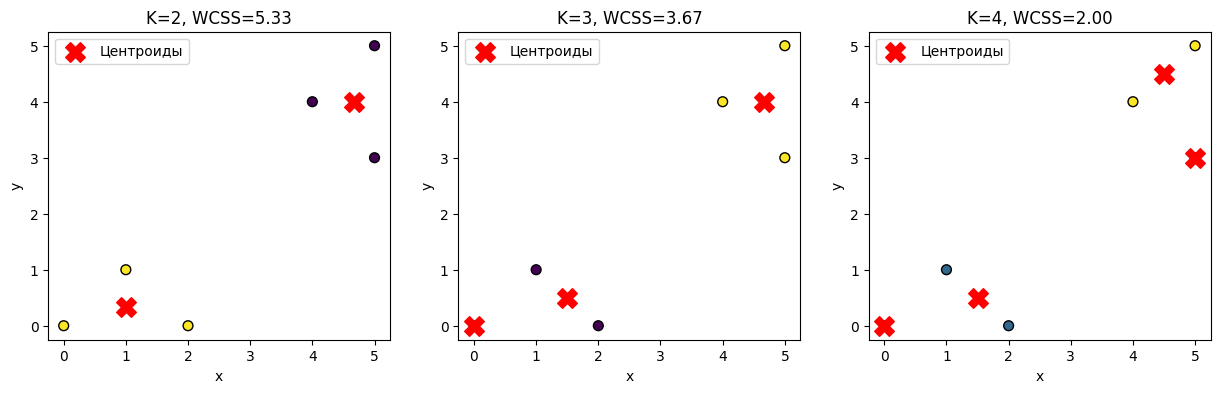

In [49]:
# Пример кластеризации данных методом k-means:
# Элементы начальной выборки: x1 = (1,1) x2 = (0,0) x3 = (2,0) x4 = (4,4) x5 = (5,5) x6 = (5,3)

x = [[1,1], [0,0] , [2,0], [4,4], [5,5], [5,3]]
X = np.array(x)
k = [2, 3, 4]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for n_clusters in k:
    centroids, labels, inertia, run_inertias = kmeans_from_scratch(X, n_clusters, seed=42)
    print(f"Best inertia for k={n_clusters}: {inertia}")
    print(f"Centroids:\n{centroids}\n")
    ax = axes[n_clusters-2]
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, edgecolor='k')
    ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Центроиды')
    ax.set_title(f'K={n_clusters}, WCSS={inertia:.2f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()

Результаты совпадают.

## Задание 3

Применить ваш алгоритм к двумерным данным из индивидуального варианта (Таблица 1).

Лучшая инерция k=2: 25.6
Центроиды:
[[1.6 1.8]
 [4.8 3.2]]

Лучшая инерция k=3: 14.333333333333334
Центроиды:
[[5.66666667 2.33333333]
 [1.6        1.8       ]
 [3.5        4.5       ]]

Лучшая инерция k=4: 6.0
Центроиды:
[[2.5        0.5       ]
 [5.66666667 2.33333333]
 [3.5        4.5       ]
 [1.         2.66666667]]

Лучшая инерция k=5: 5.166666666666666
Центроиды:
[[1.         2.66666667]
 [6.         3.        ]
 [3.5        4.5       ]
 [5.5        2.        ]
 [2.5        0.5       ]]

Лучшая инерция k=6: 3.0
Центроиды:
[[6.  2.5]
 [1.5 3. ]
 [3.5 4.5]
 [0.  2. ]
 [5.  2. ]
 [2.5 0.5]]

Лучшая инерция k=7: 2.5
Центроиды:
[[6.  2. ]
 [1.5 3. ]
 [3.5 4.5]
 [0.  2. ]
 [5.  2. ]
 [2.5 0.5]
 [6.  3. ]]

Лучшая инерция k=8: 1.5
Центроиды:
[[6.  2. ]
 [1.5 3. ]
 [3.5 4.5]
 [0.  2. ]
 [5.  2. ]
 [2.  0. ]
 [6.  3. ]
 [3.  1. ]]

Лучшая инерция k=9: 1.0
Центроиды:
[[6.  2. ]
 [1.  3. ]
 [3.5 4.5]
 [0.  2. ]
 [5.  2. ]
 [2.  0. ]
 [6.  3. ]
 [3.  1. ]
 [2.  3. ]]



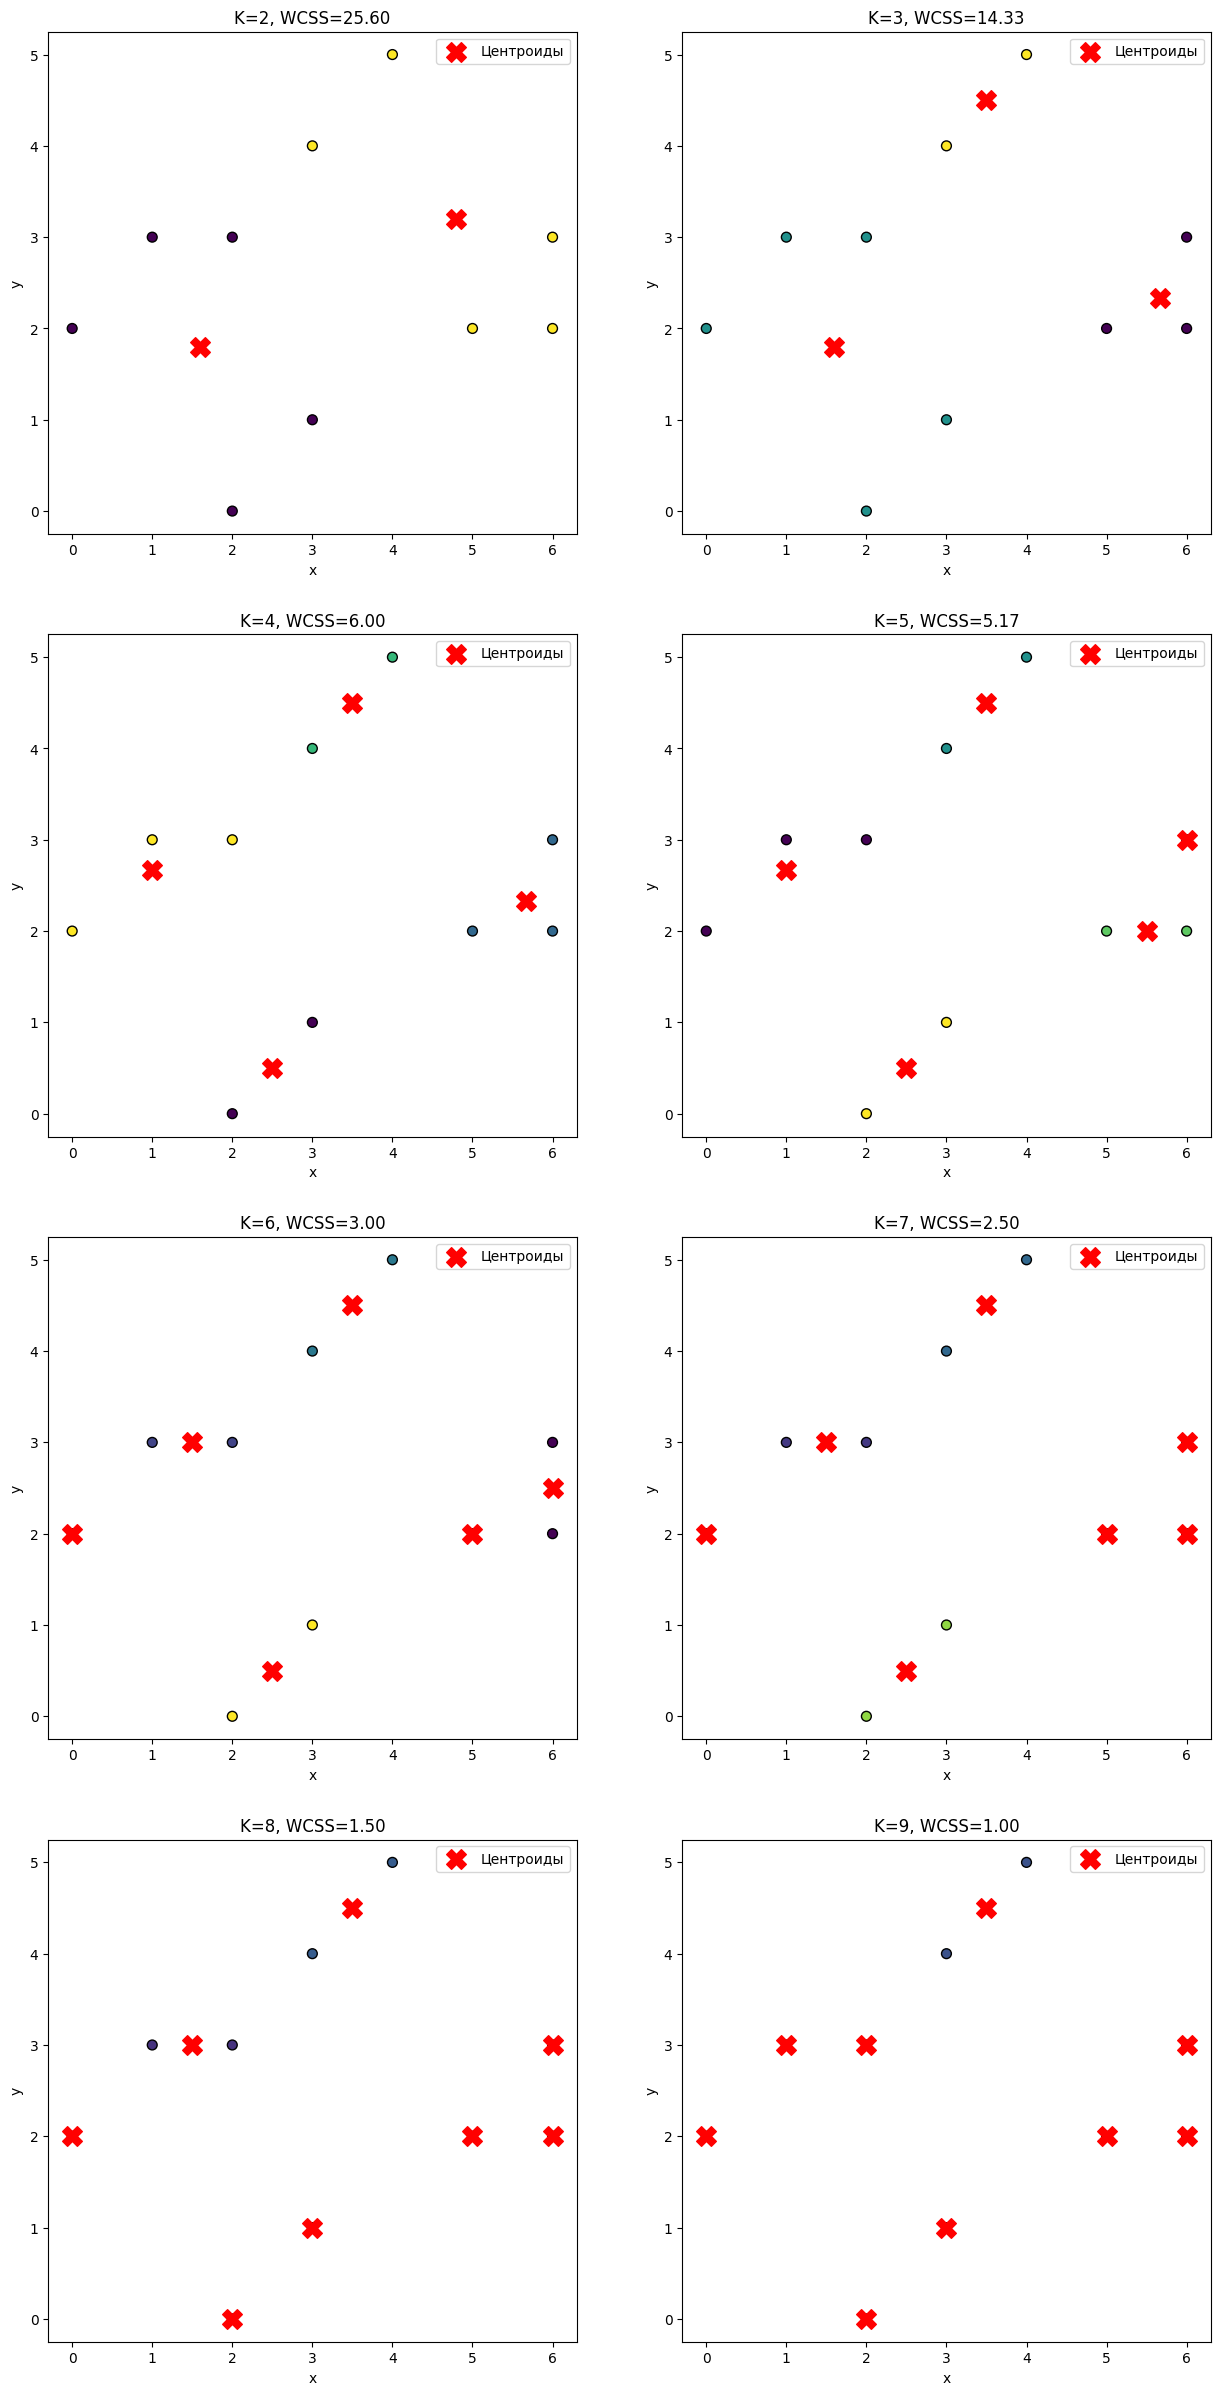

In [50]:
X =  {'x': [0,1,2,2,3,3,4,5,6,6], 'y': [2,3,0,3,1,4,5,2,2,3]}
X = np.array(list(X.values())).T

k = [_ for _ in range(2, 10)]
fig, axes = plt.subplots(4, 2, figsize=(15, 30))
wcss = []
for n_clusters in k:
    centroids, labels, inertia, run_inertias = kmeans_from_scratch(X, n_clusters, seed=42)
    print(f"Лучшая инерция k={n_clusters}: {inertia}")
    print(f"Центроиды:\n{centroids}\n")
    wcss.append([n_clusters, inertia])
    ax = axes[(n_clusters-2)//2, (n_clusters-2)%2]
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, edgecolor='k')
    ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Центроиды')
    ax.set_title(f'K={n_clusters}, WCSS={inertia:.2f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()

## Задание 4

Реализовать случайную инициализацию центров кластеров.\
 Произвести 2-3 независимых запуска для каждого разделения,\
  чтобы показать влияние начальных условий на итоговый результат.\
  ### уже реализовано

## Задание 5
Провести разделение выборки по индивидуальному варианту на 2, \
а затем на 3 и 4 кластера. Отобразить результаты на диаграмме рассеяния (scatter).\
### см задание 3

## Задание 6
Рассчитать значение внутрикластерного расстояния (сумма квадратов ошибок) \
для каждой конфигурации и выбрать наилучшую.

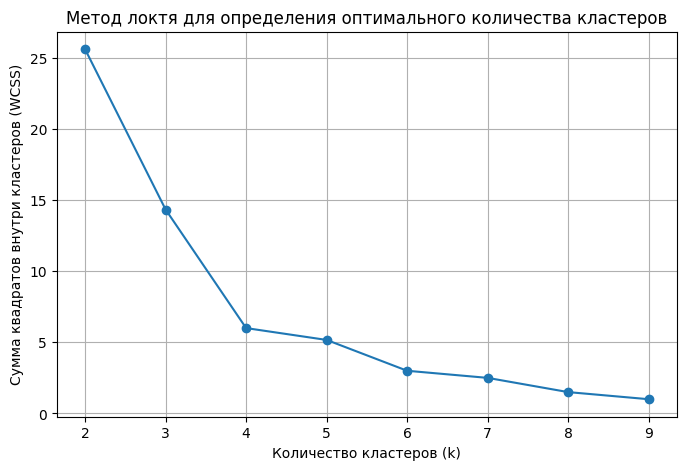

In [51]:
plt.figure(figsize=(8, 5))
wcss = np.array(wcss)
plt.plot(wcss[:, 0], wcss[:, 1], marker='o')
plt.title('Метод локтя для определения оптимального количества кластеров')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Сумма квадратов внутри кластеров (WCSS)')
plt.xticks(k)
plt.grid()
plt.show()

### Изменение переменных выходит на плато при k = 4

# Часть 2

## Задание 7

Загрузить датасет с историческими режимами работы центробежного компрессора (файл compressor_dataset.csv). 

In [52]:
df = pd.read_csv('compressor_dataset.csv')
df.head(7)

,FLOW,PIN,POUT,TIN,TOUT,RPM,VIB,AMB,MW,COMP,POWER,STATE
0,87.45,2.37,4.49,30.2,115.8,8575.0,2.26,11.5,17.02,1.893,6320.0,0
1,145.07,3.08,5.77,33.9,114.4,10342.0,2.45,24.3,15.59,1.870,8759.2,0
2,123.20,3.75,10.71,17.5,154.9,10673.0,1.42,21.8,17.17,2.859,9331.1,0
3,109.87,3.46,6.49,28.7,118.3,9470.0,2.33,-11.5,18.23,1.874,7230.3,0
4,65.60,3.61,6.89,27.2,109.3,7732.0,0.86,-11.8,17.93,1.908,6197.6,0
5,65.60,3.32,8.76,35.0,147.1,8582.0,2.10,-5.3,17.84,2.639,7123.6,1
6,55.81,3.38,7.36,37.2,133.1,7443.0,1.41,-0.1,17.28,2.175,6144.2,0


## Задание 8

 Выполнить стандартизацию данных (масштабирование) с помощью StandardScaler, \
 так как признаки имеют разный физический масштаб (расход в десятках, а обороты в тысячах).

In [53]:
scaler = StandardScaler()
scaled_df = scaler.fit_transform(df[['RPM','COMP']])
print(*scaled_df[:5], sep='\n')

[-0.62999268 -0.82746498]
[ 0.98362404 -0.88024137]
[1.28589181 1.38914346]
[ 0.18731743 -0.87106287]
[-1.39981662 -0.7930456 ]


## Задание 9

 Применить готовую реализацию метода из SciKit-Learn (sklearn.cluster.KMeans). \
 Признаки для кластеризации взять из Таблицы 2 согласно варианту.

Cреднее  внутрикластерное расстояние - 1106.048751801796


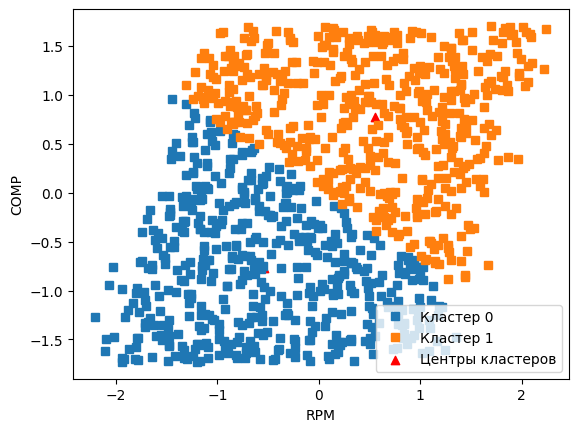

Центры кластеров:  [-0.54612421 -0.76715106]
Центры кластеров (транспонированный вектор):  [[-0.54612421]
 [-0.76715106]]


In [54]:
within_cluster_sum_of_squares = []# сумма квадратов отклонений внутри кластеров (среднее значение)

kmeans = KMeans(n_clusters=2, random_state=0, n_init=1)
kmeans.fit(scaled_df)
within_cluster_sum_of_squares.append(kmeans.inertia_)

print(f'Cреднее  внутрикластерное расстояние - {kmeans.inertia_}')
plt.figure()
plt.plot(scaled_df[:, 0][kmeans.labels_ == 0], scaled_df[:, 1][kmeans.labels_ == 0], 's')#кластер 0
plt.plot(scaled_df[:, 0][kmeans.labels_ == 1], scaled_df[:, 1][kmeans.labels_ == 1], 's')#кластер 1
plt.scatter(kmeans.cluster_centers_.T[0], kmeans.cluster_centers_.T[1], marker = '^', color = 'red')
plt.xlabel('RPM')
plt.ylabel('COMP')
plt.legend(['Кластер 0', 'Кластер 1','Центры кластеров'])
plt.show()
print('Центры кластеров: ', kmeans.cluster_centers_[0])
print('Центры кластеров (транспонированный вектор): ',kmeans.cluster_centers_[0].reshape((2,1)))

## Задание 10

Определить оптимальное количество кластеров (режимов работы) с помощью «Метода локтя» (Elbow method), \
построив график зависимости инерции (Inertia) от количества кластеров $k$ (от 1 до 10).

In [55]:
within_cluster_sum_of_squares = []
for n_clusters in range(1, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=1)
    kmeans.fit(scaled_df)
    within_cluster_sum_of_squares.append(kmeans.inertia_)

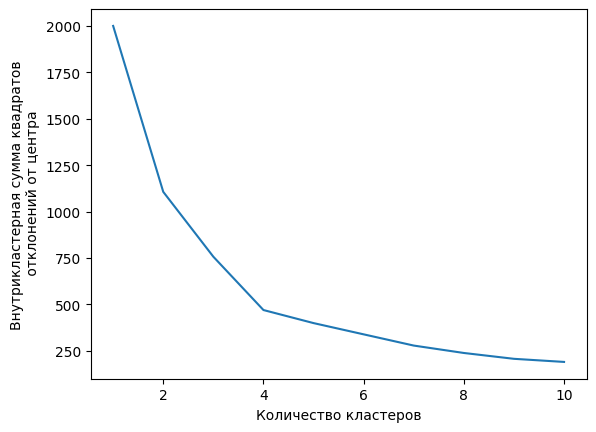

In [56]:
plt.plot(range(1, 11), within_cluster_sum_of_squares)
plt.xlabel('Количество кластеров')
plt.ylabel('Внутрикластерная сумма квадратов\n отклонений от центра')
plt.show()

### Оптимальное количество кластеров - 4, далее снижение незначительно

## Задание 11

Визуализировать полученные кластеры на 2D-графике.

Cреднее  внутрикластерное расстояние - 469.2341793250358


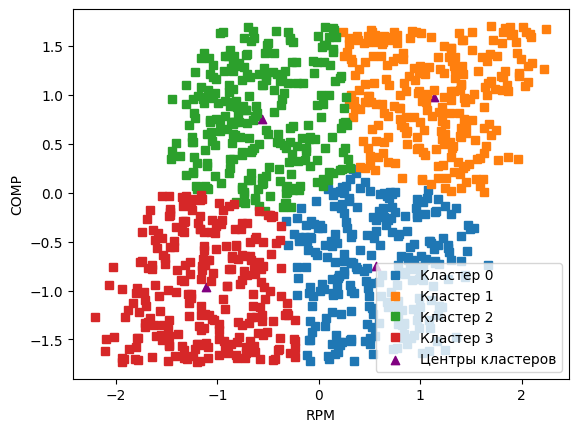

Центры кластеров:  [ 0.56049448 -0.74950191]
Центры кластеров (транспонированный вектор):  [[ 0.56049448]
 [-0.74950191]]


In [59]:
kmeans = KMeans(n_clusters=4, random_state=0, n_init=1)
kmeans.fit(scaled_df)
within_cluster_sum_of_squares.append(kmeans.inertia_)

print(f'Cреднее  внутрикластерное расстояние - {kmeans.inertia_}')
plt.figure()
plt.plot(scaled_df[:, 0][kmeans.labels_ == 0], scaled_df[:, 1][kmeans.labels_ == 0], 's')#кластер 0
plt.plot(scaled_df[:, 0][kmeans.labels_ == 1], scaled_df[:, 1][kmeans.labels_ == 1], 's')#кластер 1
plt.plot(scaled_df[:, 0][kmeans.labels_ == 2], scaled_df[:, 1][kmeans.labels_ == 2], 's')#кластер 2
plt.plot(scaled_df[:, 0][kmeans.labels_ == 3], scaled_df[:, 1][kmeans.labels_ == 3], 's')#кластер 3
plt.scatter(kmeans.cluster_centers_.T[0], kmeans.cluster_centers_.T[1], marker = '^', color = 'purple')
plt.xlabel('RPM')
plt.ylabel('COMP')
plt.legend(['Кластер 0', 'Кластер 1', 'Кластер 2', 'Кластер 3', 'Центры кластеров'])
plt.show()
print('Центры кластеров: ', kmeans.cluster_centers_[0])
print('Центры кластеров (транспонированный вектор): ',kmeans.cluster_centers_[0].reshape((2,1)))

## Задание 12

Интерпретация: Проанализировать центроиды полученных кластеров и дать им физическое объяснение \
(например: «Кластер 0 — это режим высокой нагрузки, так как средний расход и мощность здесь максимальны»).

мне кажется, что тут все очень просто - \
кластер ноль - высокие обороты и низкое давление, - высокая мощность и низкая производительность \
кластер один - высокое давление и высокие обороты,  - высокая мощность и высокая производительность\
кластер два - низкие обороты и высокое давление   - низкая мощность и высокая производительность\
кластер три - все низкое  - низкая мощность и низкая производительность


# Ответы на вопросы

1. В чем различие процессов «обучения с учителем» и «обучения без учителя»?
В обучении с учителем (supervised) алгоритму передаются размеченные данные:\
 каждому объекту соответствует известный целевой класс или значение (X → y).\
  Цель – построить функцию предсказания. \
  В обучении без учителя (unsupervised) метки y отсутствуют. \
  Алгоритм самостоятельно ищет скрытые структуры, \
  закономерности или группировки в данных (X → ?), как в случае кластеризации.
2. Как измерять сходство между данными наблюдений?
Сходство (или расстояние) измеряется с помощью метрик:
- Евклидово расстояние – для непрерывных признаков в пространстве.
- Манхэттенское – сумма модулей разностей, устойчивее к выбросам.
- Косинусное сходство – измеряет угол между векторами, полезно для текстов/частотных данных.
- Махалонобиса – учитывает корреляции и дисперсии признаков.
3. Дайте определения различных мер внутриклассового расстояния и мер расстояния между классами.
- Внутриклассовое (intra-cluster): сумма квадратов отклонений точек от центроида своего кластера (WCSS/Inertia),\
среднее попарное расстояние внутри кластера. Чем меньше – тем компактнее кластер.
- Межклассовое (inter-cluster): расстояние между центроидами кластеров, \
минимальное расстояние между точками разных кластеров, индекс Дэвиса-Болдуина. \
Чем больше – тем лучше разделены группы.
4. Почему перед применением k-means к реальным инженерным данным критически важно проводить стандартизацию?
K-means минимизирует евклидово расстояние.\
 Если признаки имеют разный масштаб (например, давление в 0.1–1.0 МПа и обороты в 3000–10000 об/мин), \
 признак с большим диапазоном будет доминировать в расчете расстояния, искажая геометрию кластеров.\
 Стандартизация приводит все признаки к нулевому среднему и единичной дисперсии, \
 обеспечивая равный вклад каждого физического параметра.
5. Как оценить качество группировки? В чем суть «Метода локтя»?
Качество оценивается метриками: Silhouette Score (от -1 до 1), индекс Дэвиса-Болдуина, Calinski-Harabasz.
Метод локтя: строится график зависимости WCSS (инерции) от числа кластеров k.\
 При увеличении k инерция всегда падает, но после определенной точки скорость падения резко снижается.\
  Эта точка перегиба («локоть») указывает на оптимальное k,\
   после которого добавление новых кластеров не дает значимого улучшения разбиения, а лишь ведет к переобучению.
6. Проанализируйте недостатки алгоритма k-means. Что произойдет, если кластеры имеют не сферическую форму?
Недостатки:
- Требует заранее задать k.
- Чувствителен к начальной инициализации и выбросам.
- Предполагает, что кластеры выпуклые, сферические и примерно одинакового размера. \
Если данные имеют вытянутую, дугообразную или кольцевую форму (например, «полумесяцы»),\
 k-means попытается разрезать их прямыми границами, создавая искусственные кластеры. \
 В таких случаях лучше использовать DBSCAN (по плотности), Agglomerative Clustering (иерархическая) \
 или Gaussian Mixture Models (эллиптические кластеры).